In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **preprocessing**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
data = 'dataset/diabetes.csv'

General Information About to the Dataset

In [ ]:
df = pd.read_csv(data)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# take a look at the shape
df.shape

(768, 9)

In [ ]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.columns.values

array(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
       'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype=object)

In [ ]:
df.groupby('Outcome').size()

Outcome
0    500
1    268
dtype: int64

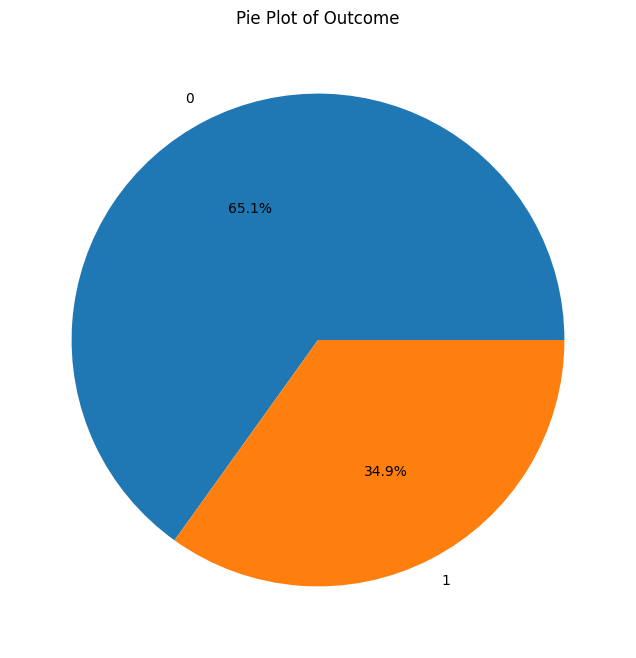

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Choose a categorical variable for the pie plot
categorical_variable = 'Outcome'

# Count the occurrences of each category
category_counts = df[categorical_variable].value_counts()

# Create a pie plot
plt.figure(figsize=(8, 8))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%')
plt.title(f'Pie Plot of {categorical_variable}')
plt.show()

In [ ]:
df.nunique()

Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

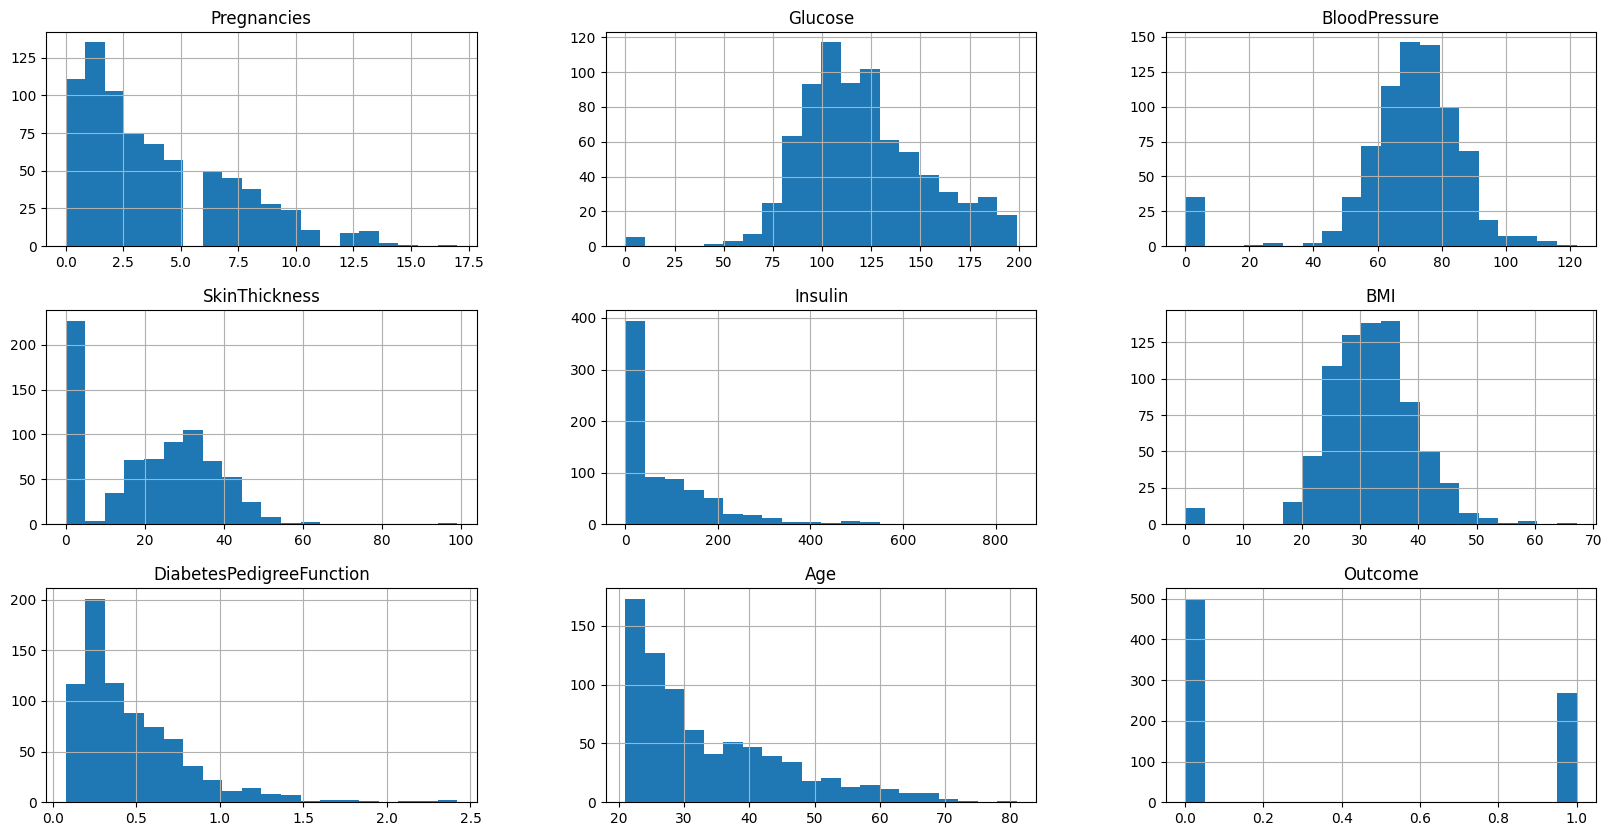

In [ ]:
df.hist(bins=20, figsize=(20,10))

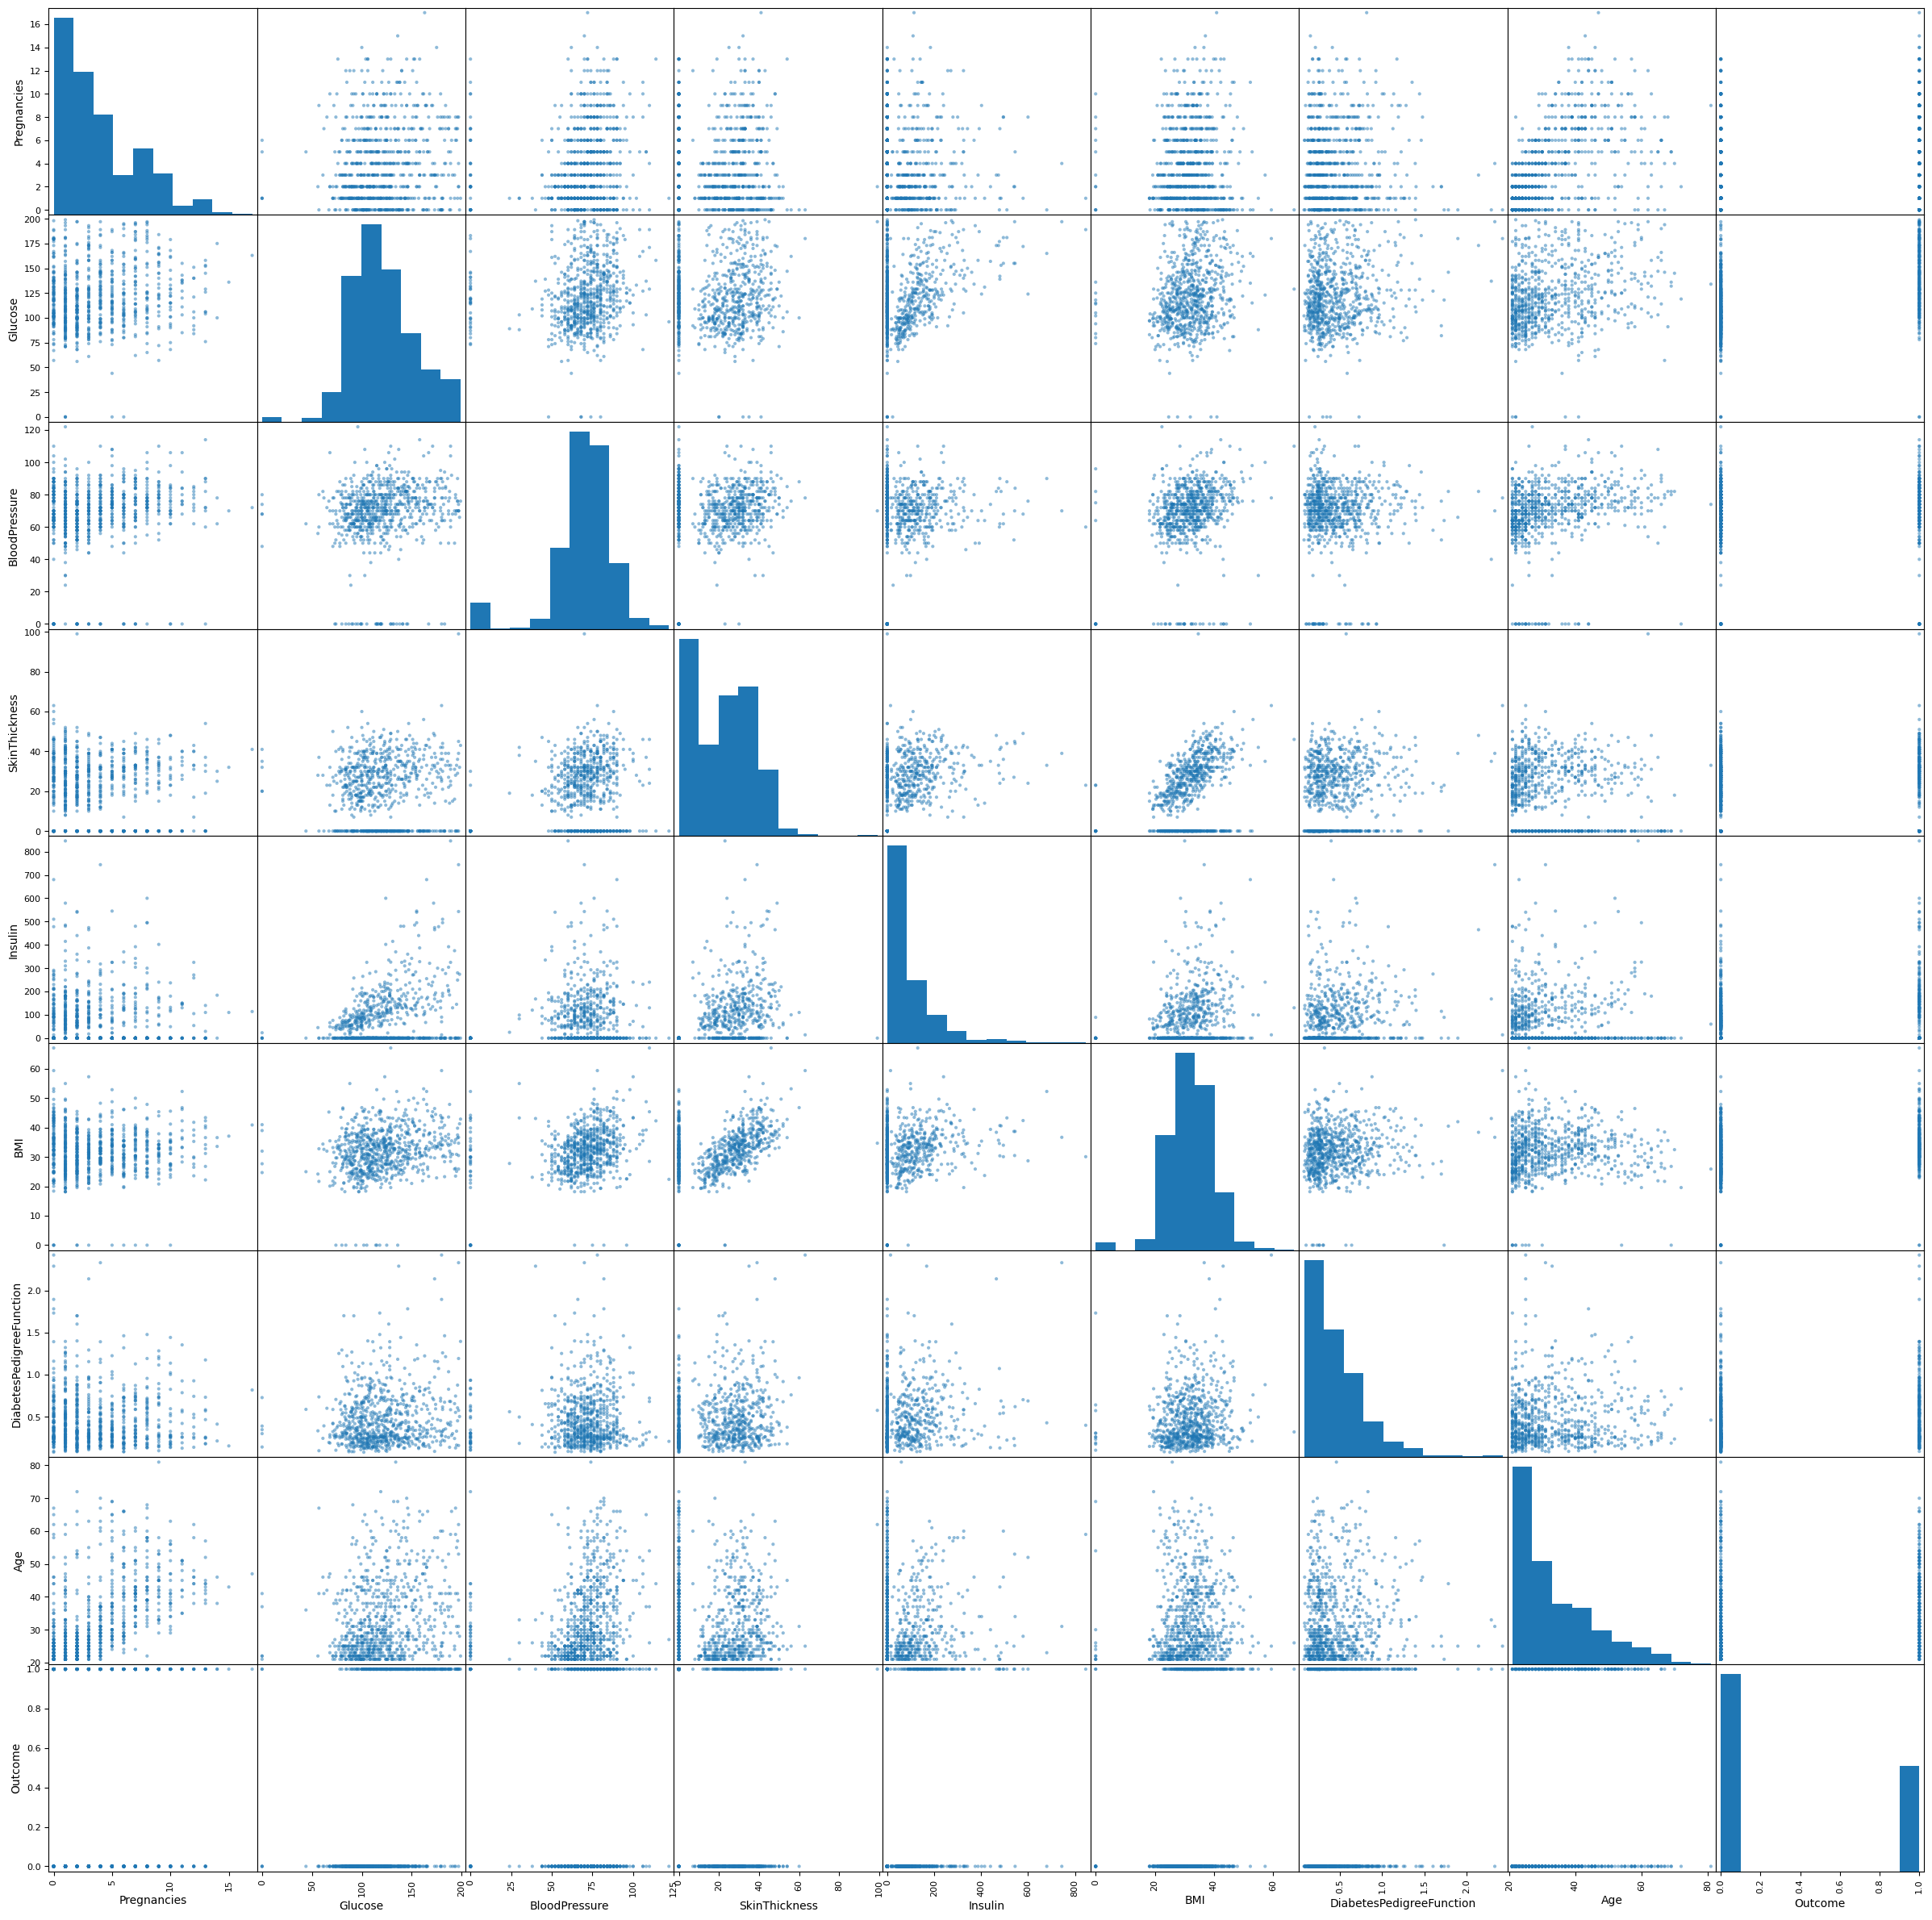

In [ ]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
#To create scatter plots for all pairs of numerical features in a DataFrame

# Scatter plot matrix
scatter_matrix(df, figsize=(30, 30), diagonal='hist', alpha=0.5)
plt.show()

Data Cleaning

In [ ]:
data = '/content/drive/MyDrive/ML_dataset/archive.zip'
df = pd.read_csv(data)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# Check for missing values
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
# Remove duplicates
df = df.drop_duplicates(inplace=True)

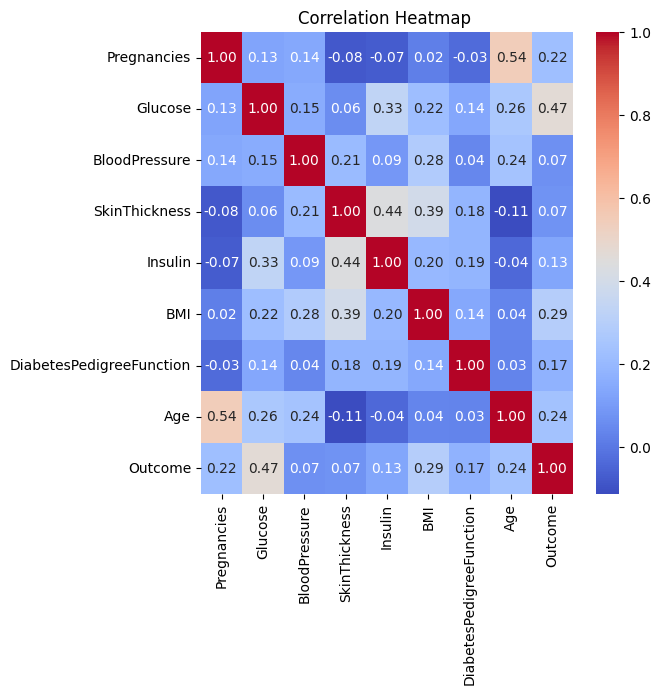

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap ')
plt.show()

Unexpected Outliers

In [ ]:
#
print('total : ', df[df.BloodPressure == 0].shape[0])
df[df.BloodPressure == 0].groupby('Outcome')['Age'].count()

total :  35


Outcome
0    19
1    16
Name: Age, dtype: int64

In [ ]:
print('total : ', df[df.Glucose == 0].shape[0])
df[df.Glucose == 0].groupby('Outcome')['Age'].count()

total :  5


Outcome
0    3
1    2
Name: Age, dtype: int64

In [ ]:
print('total : ',df[df.SkinThickness == 0].shape[0])
df[df.SkinThickness == 0].groupby('Outcome')['Age'].count()

total :  227


Outcome
0    139
1     88
Name: Age, dtype: int64

In [ ]:
print('total : ',df[df.BMI == 0].shape[0])
df[df.BMI == 0].groupby('Outcome')['Age'].count()

total :  11


Outcome
0    9
1    2
Name: Age, dtype: int64

In [ ]:
print('total : ',df[df.Insulin  == 0].shape[0])
df[df.Insulin  == 0].groupby('Outcome')['Age'].count()

total :  374


Outcome
0    236
1    138
Name: Age, dtype: int64

In [ ]:
df_mod = df[(df.BloodPressure != 0) & (df.BMI != 0) & (df.Glucose != 0)]
print(df_mod.shape)

(724, 9)


standardization

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Assuming df_mod is your DataFrame with numerical features
numerical_features = df_mod.select_dtypes(include=['float64', 'int64']).columns

# Normalize (min-max scaling)
scaler = MinMaxScaler()
df_mod[numerical_features] = scaler.fit_transform(df_mod[numerical_features])
print(df_mod)

     Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0       0.352941  0.670968       0.489796       0.353535  0.000000  0.314928   
1       0.058824  0.264516       0.428571       0.292929  0.000000  0.171779   
2       0.470588  0.896774       0.408163       0.000000  0.000000  0.104294   
3       0.058824  0.290323       0.428571       0.232323  0.111111  0.202454   
4       0.000000  0.600000       0.163265       0.353535  0.198582  0.509202   
..           ...       ...            ...            ...       ...       ...   
763     0.588235  0.367742       0.530612       0.484848  0.212766  0.300613   
764     0.117647  0.503226       0.469388       0.272727  0.000000  0.380368   
765     0.294118  0.496774       0.489796       0.232323  0.132388  0.163599   
766     0.058824  0.529032       0.367347       0.000000  0.000000  0.243354   
767     0.058824  0.316129       0.469388       0.313131  0.000000  0.249489   

     DiabetesPedigreeFunction       Age

<ipython-input-269-c7bf757909fc>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mod[numerical_features] = scaler.fit_transform(df_mod[numerical_features])


In [ ]:
df_mod.to_csv('cleaned_dataset.csv', index=False)

## **Logistic Regression**

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
# Load the diabetes dataset
diabetes_df = pd.read_csv('/content/cleaned_dataset.csv')

In [ ]:
# Display the first few rows of the dataset
print(diabetes_df.head())

   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.352941  0.670968       0.489796       0.353535  0.000000  0.314928   
1     0.058824  0.264516       0.428571       0.292929  0.000000  0.171779   
2     0.470588  0.896774       0.408163       0.000000  0.000000  0.104294   
3     0.058824  0.290323       0.428571       0.232323  0.111111  0.202454   
4     0.000000  0.600000       0.163265       0.353535  0.198582  0.509202   

   DiabetesPedigreeFunction       Age  Outcome  
0                  0.234415  0.483333      1.0  
1                  0.116567  0.166667      0.0  
2                  0.253629  0.183333      1.0  
3                  0.038002  0.000000      0.0  
4                  0.943638  0.200000      1.0  


In [ ]:
# Preprocessing
X = diabetes_df.drop('Outcome', axis=1)
y = diabetes_df['Outcome']

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train[:5]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
446,0.000000,0.600000,0.612245,0.272727,0.000000,0.186094,0.065329,0.633333
6,0.176471,0.219355,0.265306,0.323232,0.104019,0.261759,0.072588,0.083333
423,0.058824,0.245161,0.408163,0.131313,0.112293,0.061350,0.143894,0.033333
596,0.764706,0.387097,0.489796,0.000000,0.000000,0.265849,0.165243,0.283333
411,0.058824,0.341935,0.469388,0.151515,0.000000,0.000000,0.029462,0.000000


In [ ]:
y_train[:5]

446    0.0
6      1.0
423    0.0
596    1.0
411    0.0
Name: Outcome, dtype: float64

In [ ]:
# Create Logistic Regression model
model = LogisticRegression()

In [ ]:
# Train the model
model.fit(X_train, y_train)
# Make predictions on the test set
y_pred = model.predict(X_test)

Model Evaluation

In [ ]:

# Accuracy
accuracy_LR = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy_LR:.2f}")

# Precision
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.2f}")

# F1-score
f1 = f1_score(y_test, y_pred)
print(f"F1-score: {f1:.2f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)


Accuracy: 0.81
Precision: 0.71
F1-score: 0.67
Confusion Matrix:
 [[91 11]
 [16 27]]


In [ ]:
classification_rep = classification_report(y_test, y_pred)
print("\nClassification Report:\n", classification_rep)


Classification Report:
               precision    recall  f1-score   support

         0.0       0.85      0.89      0.87       102
         1.0       0.71      0.63      0.67        43

    accuracy                           0.81       145
   macro avg       0.78      0.76      0.77       145
weighted avg       0.81      0.81      0.81       145



## **Decision Tree**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn import tree
import matplotlib.pyplot as plt

In [ ]:
# Load the diabetes dataset
diabetes_df = pd.read_csv('/content/cleaned_dataset.csv')

In [ ]:
# Preprocessing
X = diabetes_df.drop('Outcome', axis=1)
y = diabetes_df['Outcome']

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train[:5]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
446,0.000000,0.600000,0.612245,0.272727,0.000000,0.186094,0.065329,0.633333
6,0.176471,0.219355,0.265306,0.323232,0.104019,0.261759,0.072588,0.083333
423,0.058824,0.245161,0.408163,0.131313,0.112293,0.061350,0.143894,0.033333
596,0.764706,0.387097,0.489796,0.000000,0.000000,0.265849,0.165243,0.283333
411,0.058824,0.341935,0.469388,0.151515,0.000000,0.000000,0.029462,0.000000


In [ ]:
y_train[:5]

446    0.0
6      1.0
423    0.0
596    1.0
411    0.0
Name: Outcome, dtype: float64

In [ ]:
# Create Decision Tree model
model = DecisionTreeClassifier(random_state=42)

In [ ]:
# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

Model Evaluation


In [ ]:
# Accuracy
accuracy_DT = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy_DT:.2f}")

# Precision
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.2f}")

# Recall
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.2f}")


# F1-score
f1 = f1_score(y_test, y_pred)
print(f"F1-score: {f1:.2f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

Decision Tree Accuracy: 0.72
Precision: 0.52
Recall: 0.63
F1-score: 0.57
Confusion Matrix:
 [[77 25]
 [16 27]]


In [ ]:
classification_rep = classification_report(y_test, y_pred)
print("\nClassification Report:\n", classification_rep)



Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.75      0.79       102
         1.0       0.52      0.63      0.57        43

    accuracy                           0.72       145
   macro avg       0.67      0.69      0.68       145
weighted avg       0.74      0.72      0.72       145



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Predict probabilities on the test set (for Decision Tree, it doesn't directly provide probabilities, so let's use predicted values)
y_pred_proba = model.predict(X_test)
print(y_pred_proba)

# Print the predicted probabilities for the first row
print("Predicted Probabilities for the First Row:")
print(y_pred_proba[0])

[0. 0. 1. 1. 1. 0. 1. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0.
 1. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1.
 1. 1. 0. 1. 1. 0. 1. 1. 0. 0. 1. 0. 1. 1. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0.
 1. 0. 0. 1. 1. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 1. 1. 0. 1. 0. 0. 1. 0.
 0. 1. 0. 1. 0. 1. 1. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 1.
 1.]
Predicted Probabilities for the First Row:
0.0


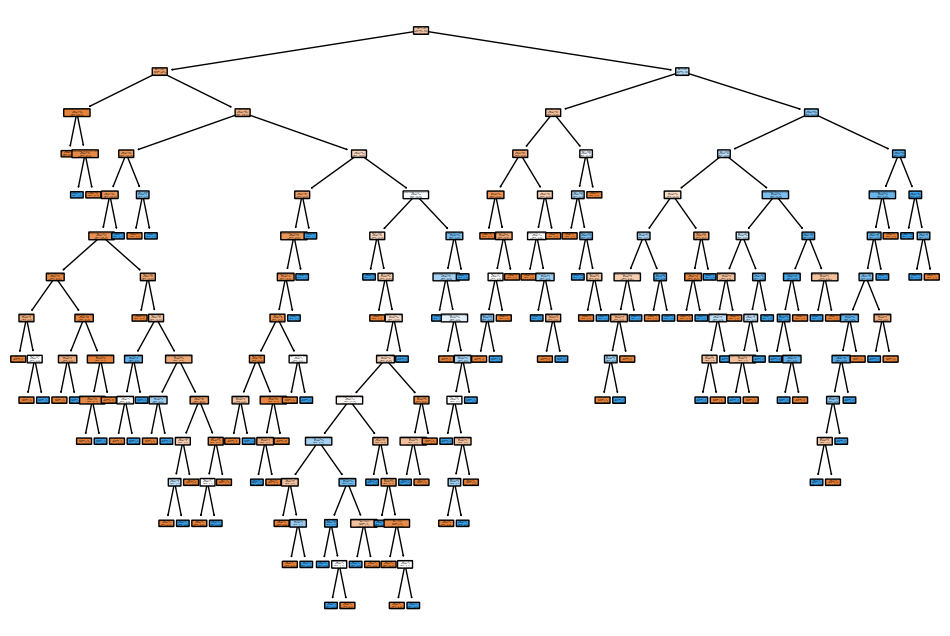

In [ ]:
# Visualize the Decision Tree
plt.figure(figsize=(12, 8))
tree.plot_tree(model, feature_names=X.columns, class_names=['No Diabetes', 'Diabetes'], filled=True, rounded=True)
plt.show()

## **GradientBoosting**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Load the diabetes dataset
diabetes_df = pd.read_csv('/content/cleaned_dataset.csv')

In [ ]:
# Preprocessing
X = diabetes_df.drop('Outcome', axis=1)
y = diabetes_df['Outcome']

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train[:5]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
446,0.000000,0.600000,0.612245,0.272727,0.000000,0.186094,0.065329,0.633333
6,0.176471,0.219355,0.265306,0.323232,0.104019,0.261759,0.072588,0.083333
423,0.058824,0.245161,0.408163,0.131313,0.112293,0.061350,0.143894,0.033333
596,0.764706,0.387097,0.489796,0.000000,0.000000,0.265849,0.165243,0.283333
411,0.058824,0.341935,0.469388,0.151515,0.000000,0.000000,0.029462,0.000000


In [ ]:
y_train[:5]

446    0.0
6      1.0
423    0.0
596    1.0
411    0.0
Name: Outcome, dtype: float64

In [ ]:
# Create Gradient Boosting model
model = GradientBoostingClassifier(random_state=42)

In [ ]:
# Train the model
model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred

array([0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
       0., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0.,
       0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 1., 1., 0., 1., 0., 1., 0.,
       0., 1., 0., 1., 1., 0., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0.,
       1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 1., 0.,
       1., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 1., 1., 0., 1., 1., 1., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0.,
       0., 0., 1., 0., 1., 0., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0.,
       0., 1., 0., 1., 0., 0., 0., 1., 0.])

Model Evaluation

In [ ]:
# Accuracy
accuracy_GB = accuracy_score(y_test, y_pred)
print(f"Gradient Boosting Accuracy: {accuracy_GB:.2f}")

# Precision
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.2f}")

# Recall
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.2f}")

# F1-score
f1 = f1_score(y_test, y_pred)
print(f"F1-score: {f1:.2f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

Gradient Boosting Accuracy: 0.81
Precision: 0.67
Recall: 0.72
F1-score: 0.70
Confusion Matrix:
 [[87 15]
 [12 31]]


In [ ]:
classification_rep = classification_report(y_test, y_pred)
print("\nClassification Report:\n", classification_rep)


Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.85      0.87       102
         1.0       0.67      0.72      0.70        43

    accuracy                           0.81       145
   macro avg       0.78      0.79      0.78       145
weighted avg       0.82      0.81      0.82       145



## **Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Load the diabetes dataset
diabetes_df = pd.read_csv('/content/cleaned_dataset.csv')

In [ ]:
# Preprocessing
X = diabetes_df.drop('Outcome', axis=1)
y = diabetes_df['Outcome']

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train[:5]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
446,0.000000,0.600000,0.612245,0.272727,0.000000,0.186094,0.065329,0.633333
6,0.176471,0.219355,0.265306,0.323232,0.104019,0.261759,0.072588,0.083333
423,0.058824,0.245161,0.408163,0.131313,0.112293,0.061350,0.143894,0.033333
596,0.764706,0.387097,0.489796,0.000000,0.000000,0.265849,0.165243,0.283333
411,0.058824,0.341935,0.469388,0.151515,0.000000,0.000000,0.029462,0.000000


In [ ]:
y_train[:5]

446    0.0
6      1.0
423    0.0
596    1.0
411    0.0
Name: Outcome, dtype: float64

In [ ]:
# Create Random Forest model
model = RandomForestClassifier(random_state=42)

In [ ]:
# Train the model
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred

array([0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 1., 0.,
       0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 1., 0., 0., 1., 1., 1., 0.,
       0., 1., 0., 1., 1., 0., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0.,
       1., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0.,
       1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 1., 1., 0., 1., 1., 1., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0.,
       0., 0., 1., 0., 1., 0., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0.,
       0., 1., 0., 1., 0., 0., 0., 1., 0.])

Model Evaluation

In [ ]:
# Accuracy
accuracy_RF = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy_RF:.2f}")

# Precision
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.2f}")

# Recall
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.2f}")

# F1-score
f1 = f1_score(y_test, y_pred)
print(f"F1-score: {f1:.2f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

Random Forest Accuracy: 0.80
Precision: 0.66
Recall: 0.67
F1-score: 0.67
Confusion Matrix:
 [[87 15]
 [14 29]]


In [ ]:
classification_rep = classification_report(y_test, y_pred)
print("\nClassification Report:\n", classification_rep)


Classification Report:
               precision    recall  f1-score   support

         0.0       0.86      0.85      0.86       102
         1.0       0.66      0.67      0.67        43

    accuracy                           0.80       145
   macro avg       0.76      0.76      0.76       145
weighted avg       0.80      0.80      0.80       145



## **Support Vector Machine**

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import pandas as pd

In [ ]:
# Load the diabetes dataset
diabetes_df = pd.read_csv('/content/cleaned_dataset.csv')

In [ ]:
# Preprocessing
X = diabetes_df.drop('Outcome', axis=1)
y = diabetes_df['Outcome']

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train[:5]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
446,0.000000,0.600000,0.612245,0.272727,0.000000,0.186094,0.065329,0.633333
6,0.176471,0.219355,0.265306,0.323232,0.104019,0.261759,0.072588,0.083333
423,0.058824,0.245161,0.408163,0.131313,0.112293,0.061350,0.143894,0.033333
596,0.764706,0.387097,0.489796,0.000000,0.000000,0.265849,0.165243,0.283333
411,0.058824,0.341935,0.469388,0.151515,0.000000,0.000000,0.029462,0.000000


In [ ]:
y_train[:5]

446    0.0
6      1.0
423    0.0
596    1.0
411    0.0
Name: Outcome, dtype: float64

In [ ]:
# Create SVM model
model = SVC(kernel='linear', random_state=42)  # Linear kernel for simplicity

In [ ]:
# Train the model
model.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

Model Evaluation

In [ ]:
# Accuracy
accuracy_SVM = accuracy_score(y_test, y_pred)
print(f"SVM Accuracy: {accuracy_SVM:.2f}")

# Precision
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.2f}")

# Recall
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.2f}")

# F1-score
f1 = f1_score(y_test, y_pred)
print(f"F1-score: {f1:.2f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)


SVM Accuracy: 0.80
Precision: 0.68
Recall: 0.60
F1-score: 0.64
Confusion Matrix:
 [[90 12]
 [17 26]]


In [ ]:
classification_rep = classification_report(y_test, y_pred)
print("\nClassification Report:\n", classification_rep)


Classification Report:
               precision    recall  f1-score   support

         0.0       0.84      0.88      0.86       102
         1.0       0.68      0.60      0.64        43

    accuracy                           0.80       145
   macro avg       0.76      0.74      0.75       145
weighted avg       0.79      0.80      0.80       145



## **Neural Network**

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Load the diabetes dataset
diabetes_df = pd.read_csv('/content/cleaned_dataset.csv')

In [ ]:
# Preprocessing
X = diabetes_df.drop('Outcome', axis=1)
y = diabetes_df['Outcome']

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train[:5]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
446,0.000000,0.600000,0.612245,0.272727,0.000000,0.186094,0.065329,0.633333
6,0.176471,0.219355,0.265306,0.323232,0.104019,0.261759,0.072588,0.083333
423,0.058824,0.245161,0.408163,0.131313,0.112293,0.061350,0.143894,0.033333
596,0.764706,0.387097,0.489796,0.000000,0.000000,0.265849,0.165243,0.283333
411,0.058824,0.341935,0.469388,0.151515,0.000000,0.000000,0.029462,0.000000


In [ ]:
y_train[:5]

446    0.0
6      1.0
423    0.0
596    1.0
411    0.0
Name: Outcome, dtype: float64

In [ ]:
# Create Neural Network model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(64, activation='softmax'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])


In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/10
19/19 [==============================] - 1s 14ms/step - loss: 0.6909 - accuracy: 0.5976 - val_loss: 0.6846 - val_accuracy: 0.7034
Epoch 2/10
19/19 [==============================] - 0s 5ms/step - loss: 0.6848 - accuracy: 0.6442 - val_loss: 0.6761 - val_accuracy: 0.7034
Epoch 3/10
19/19 [==============================] - 0s 5ms/step - loss: 0.6798 - accuracy: 0.6442 - val_loss: 0.6692 - val_accuracy: 0.7034
Epoch 4/10
19/19 [==============================] - 0s 4ms/step - loss: 0.6750 - accuracy: 0.6442 - val_loss: 0.6615 - val_accuracy: 0.7034
Epoch 5/10
19/19 [==============================] - 0s 4ms/step - loss: 0.6703 - accuracy: 0.6442 - val_loss: 0.6541 - val_accuracy: 0.7034
Epoch 6/10
19/19 [==============================] - 0s 5ms/step - loss: 0.6666 - accuracy: 0.6442 - val_loss: 0.6479 - val_accuracy: 0.7034
Epoch 7/10
19/19 [==============================] - 0s 4ms/step - loss: 0.6632 - accuracy: 0.6442 - val_loss: 0.6410 - val_accuracy: 0.7034
Epoch 8/10
19/19 [=

In [ ]:
# Evaluate the model on the test set
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)
y_pred

5/5 [==============================] - 0s 3ms/step


array([[0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
    

Model Evaluation

In [ ]:
# Accuracy
accuracy_NN = accuracy_score(y_test, y_pred)
print(f"Neural Network Accuracy: {accuracy_NN:.2f}")

# Precision
precision = precision_score(y_test, y_pred, zero_division=1)
print(f"Precision: {precision:.2f}")

# Recall
recall = recall_score(y_test, y_pred, zero_division=1)
print(f"Recall: {recall:.2f}")

# F1-score
f1 = f1_score(y_test, y_pred, zero_division=1)
print(f"F1-score: {f1:.2f}")


# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)


Neural Network Accuracy: 0.70
Precision: 1.00
Recall: 0.00
F1-score: 0.00
Confusion Matrix:
 [[102   0]
 [ 43   0]]


In [ ]:
classification_rep = classification_report(y_test, y_pred, zero_division=1)
print("\nClassification Report:\n", classification_rep)


Classification Report:
               precision    recall  f1-score   support

         0.0       0.70      1.00      0.83       102
         1.0       1.00      0.00      0.00        43

    accuracy                           0.70       145
   macro avg       0.85      0.50      0.41       145
weighted avg       0.79      0.70      0.58       145



## **Model Comparison**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
# Create instances of each model
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Gradient Boosting':  GradientBoostingClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Support Vector Machine': SVC(),
    'Neural Network': MLPClassifier()
}


Logistic Regression Evaluation Metrics:
Accuracy: 0.81
Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.89      0.87       102
         1.0       0.71      0.63      0.67        43

    accuracy                           0.81       145
   macro avg       0.78      0.76      0.77       145
weighted avg       0.81      0.81      0.81       145



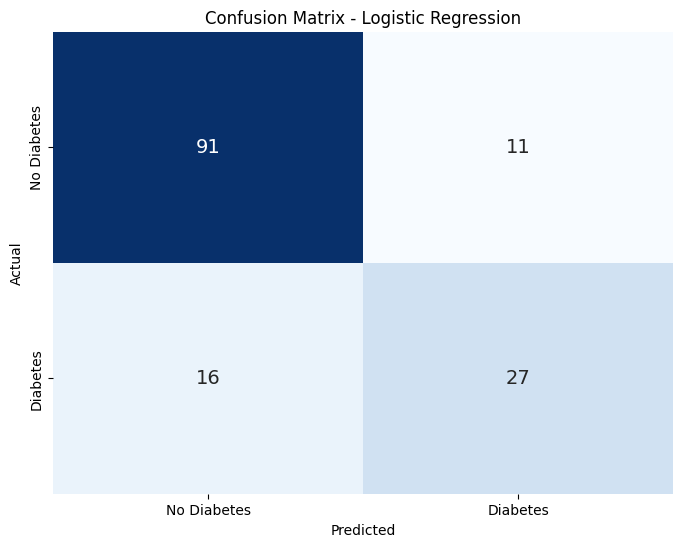


Decision Tree Evaluation Metrics:
Accuracy: 0.77
Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.78      0.83       102
         1.0       0.59      0.74      0.66        43

    accuracy                           0.77       145
   macro avg       0.74      0.76      0.74       145
weighted avg       0.79      0.77      0.78       145



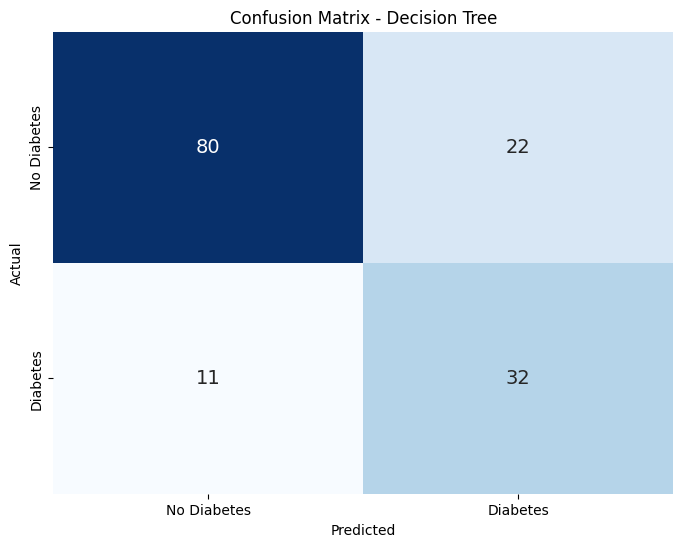


Gradient Boosting Evaluation Metrics:
Accuracy: 0.81
Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.84      0.86       102
         1.0       0.66      0.72      0.69        43

    accuracy                           0.81       145
   macro avg       0.77      0.78      0.77       145
weighted avg       0.81      0.81      0.81       145



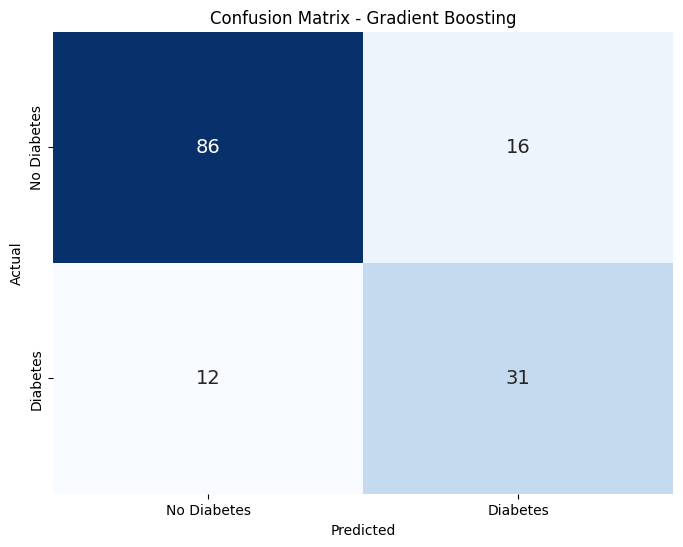


Random Forest Evaluation Metrics:
Accuracy: 0.80
Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.83      0.85       102
         1.0       0.65      0.72      0.68        43

    accuracy                           0.80       145
   macro avg       0.76      0.78      0.77       145
weighted avg       0.81      0.80      0.80       145



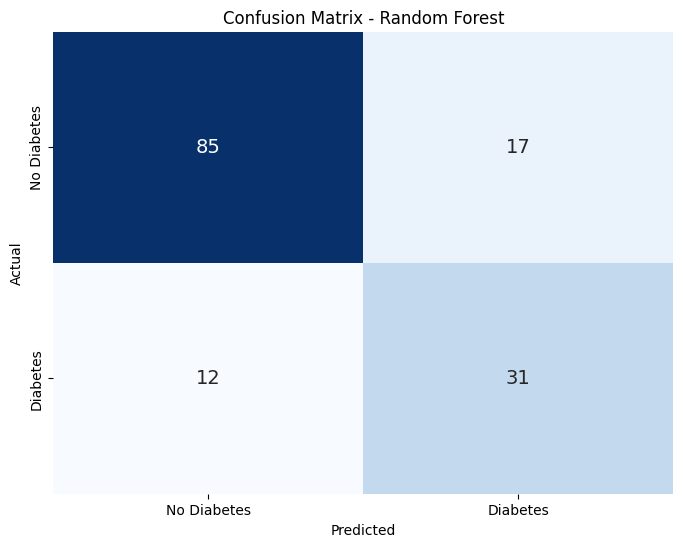


Support Vector Machine Evaluation Metrics:
Accuracy: 0.77
Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.84      0.84       102
         1.0       0.62      0.60      0.61        43

    accuracy                           0.77       145
   macro avg       0.73      0.72      0.73       145
weighted avg       0.77      0.77      0.77       145



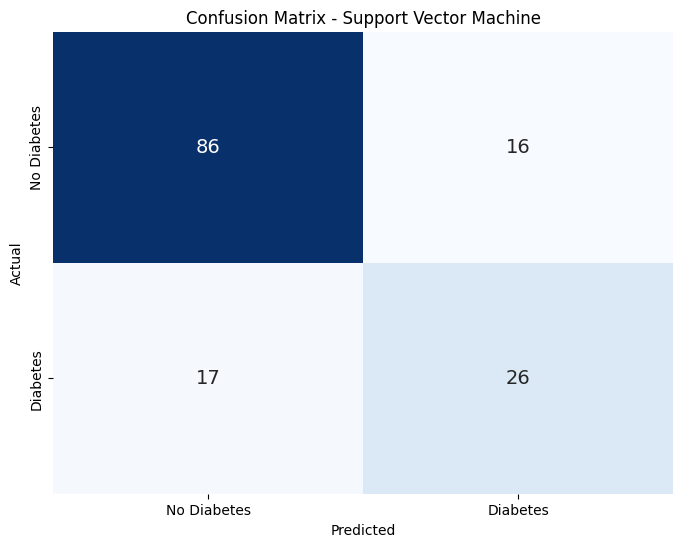

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(



Neural Network Evaluation Metrics:
Accuracy: 0.80
Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.87      0.86       102
         1.0       0.68      0.63      0.65        43

    accuracy                           0.80       145
   macro avg       0.76      0.75      0.76       145
weighted avg       0.80      0.80      0.80       145



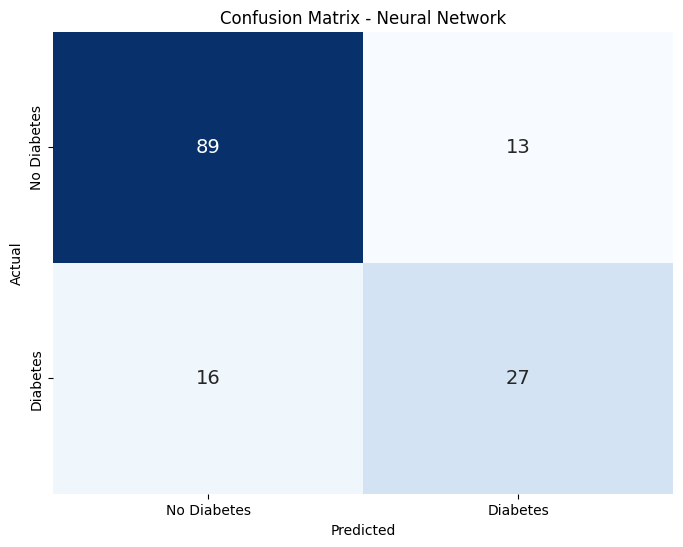

In [ ]:
# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Print evaluation metrics
    print(f'\n{name} Evaluation Metrics:')
    print(f'Accuracy: {accuracy_score(y_test, y_pred):.2f}')
    print(f'Classification Report:\n{classification_report(y_test, y_pred)}')

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                annot_kws={'size': 14}, xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


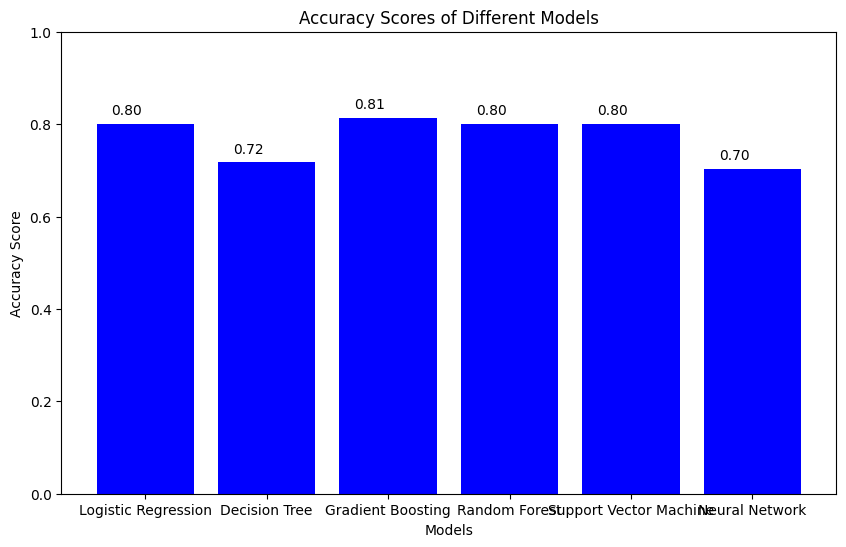

In [ ]:

#Certainly! You can add the numerical values of accuracy on top of each bar in the bar chart. Here's an updated version of the code that includes the numerical values:

# python
# Copy code
# List of models and their accuracy scores
models = ['Logistic Regression', 'Decision Tree', 'Gradient Boosting', 'Random Forest', 'Support Vector Machine', 'Neural Network']
accuracy_scores = [accuracy_LR, accuracy_DT, accuracy_GB, accuracy_RF, accuracy_SVM, accuracy_NN]

# Plotting the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracy_scores, color='blue')
plt.xlabel('Models')
plt.ylabel('Accuracy Score')
plt.title('Accuracy Scores of Different Models')
plt.ylim(0, 1)  # Set y-axis limit between 0 and 1 for accuracy scores

# Adding the numerical values on top of each bar
for bar, accuracy in zip(bars, accuracy_scores):
    plt.text(bar.get_x() + bar.get_width() / 2 - 0.15, bar.get_height() + 0.02, f'{accuracy:.2f}', ha='center', color='black')

plt.show()